# Ionisation balance of iron in a Type Ia supernova at 250 days

This notebook uses the ionisation balance of `pynonthermal` to find the ion fractions of iron in the
core of a Type Ia supernova (SN Ia) in the nebular phase. At 250 days after the explosion the ejecta
are optically thin to most of the radiation, and the energy input is the decay of 56Co to 56Fe. The
positrons (and the small fraction of the gamma rays that is absorbed) make fast electrons, which
ionise, excite, and heat the gas. In the iron-rich core, non-thermal ionisation by these fast
electrons is the main ionisation process, and recombination balances it.

The steps are:

1. Set the conditions of the iron core at 250 days: the iron number density, the temperature, and
   the deposition rate density from the 56Co decay.
2. Give the recombination rate coefficients of the iron ions to `add_element_ionbalance()`.
3. Let `solve()` iterate the non-thermal ionisation rates against recombination, and read the ion
   fractions and the free electron density.
4. Compare with the Saha equation at the same temperature, and follow the balance from 150 to 400
   days.

The physics that is left out: photoionisation, thermal collisional ionisation, charge exchange,
and time dependence (the balance is a steady state at each epoch). The recombination rate
coefficients below are round, illustrative values. Replace them with values from a recombination
database at your temperature.

In [1]:
import math

import matplotlib.pyplot as plt
import matplotlib_inline.backend_inline

import pynonthermal

matplotlib_inline.backend_inline.set_matplotlib_formats("svg")

## Conditions in the iron core at 250 days

The ejecta expand homologously, so the density falls as $t^{-3}$. A typical iron number density in
the core of a Chandrasekhar-mass model at 250 days is about $10^6$ cm$^{-3}$, and the electron
temperature from nebular spectra is 5000 to 8000 K.

The decay chain 56Ni (half-life 6.075 d) to 56Co (half-life 77.24 d) to 56Fe gives the deposition
rate density. We take all of the iron to come from 56Ni. Each 56Co decay releases on average
0.12 MeV in positron kinetic energy (a 19 per cent branch with a mean energy of 0.63 MeV) and
3.6 MeV in gamma rays. The positrons deposit their energy locally. The ejecta are nearly transparent
to gamma rays at this epoch, so only a small fraction `f_gamma` of the gamma-ray energy is
deposited. We use 0.03 at 250 days and scale it as $t^{-2}$ (the gamma-ray optical depth of
homologous ejecta).

In [2]:
T_DAYS = 250.0
N_FE_250 = 1.0e6  # iron number density [cm^-3] at 250 days
TEMPERATURE = 6000.0  # electron temperature [K]

HALFLIFE_NI56_DAYS = 6.075
HALFLIFE_CO56_DAYS = 77.24
E_POSITRON_EV = 0.12e6  # mean positron kinetic energy per 56Co decay [eV]
E_GAMMA_EV = 3.6e6  # mean gamma-ray energy per 56Co decay [eV]
F_GAMMA_250 = 0.03  # fraction of the gamma-ray energy deposited at 250 days


def get_n_fe(t_days: float) -> float:
    # homologous expansion: the density falls as t^-3
    return N_FE_250 * (T_DAYS / t_days) ** 3


def get_deposition_rate_density(t_days: float) -> float:
    # energy deposition rate density [eV s^-1 cm^-3] from the 56Co decays in the iron core
    tau_ni = HALFLIFE_NI56_DAYS / math.log(2)
    tau_co = HALFLIFE_CO56_DAYS / math.log(2)
    # 56Co nuclei per initial 56Ni nucleus (Bateman equation)
    co_per_ni0 = tau_co / (tau_co - tau_ni) * (math.exp(-t_days / tau_co) - math.exp(-t_days / tau_ni))
    decays_per_second_per_fe = co_per_ni0 / (tau_co * 86400.0)
    f_gamma = F_GAMMA_250 * (T_DAYS / t_days) ** 2
    return get_n_fe(t_days) * decays_per_second_per_fe * (E_POSITRON_EV + f_gamma * E_GAMMA_EV)


deposition_250 = get_deposition_rate_density(T_DAYS)
print(f"iron number density: {N_FE_250:.2e} cm^-3")
print(f"deposition rate density: {deposition_250:.1f} eV s^-1 cm^-3")
print(f"deposition per iron nucleus: {deposition_250 / N_FE_250:.2e} eV s^-1")

iron number density: 1.00e+06 cm^-3
deposition rate density: 2726.8 eV s^-1 cm^-3
deposition per iron nucleus: 2.73e-03 eV s^-1


## Recombination rate coefficients

`add_element_ionbalance()` takes the recombination rate coefficients in cm$^3$ s$^{-1}$, keyed by
the ion stage that recombines. The chain of ion stages then runs from one below the lowest key to
the highest key: here Fe I to Fe VII. The top stage is a sink, so the chain must end at a stage whose
ionisation rate is negligible, or `solve()` warns.

The values below are round numbers of the order of the total (radiative plus dielectronic)
recombination rate coefficients of the iron ions near 6000 K. For a real model, take the values at
your temperature from a recombination database, for example the fits of Shull, J. M. & van
Steenberg, M. (1982), "Ionization equilibrium of astrophysically abundant elements", The
Astrophysical Journal Supplement Series, 48, 95-107, DOI 10.1086/190769, or the unified
recombination rate coefficients of Nahar and collaborators.

In [3]:
# recombination rate coefficients [cm^3 s^-1] keyed by the ion stage that recombines:
# Fe II -> Fe I, Fe III -> Fe II, ..., Fe VII -> Fe VI
RECOMB_RATECOEFFS_FE = {2: 1.0e-11, 3: 1.5e-11, 4: 3.0e-11, 5: 6.0e-11, 6: 1.0e-10, 7: 1.5e-10}
ION_STAGES = list(range(1, max(RECOMB_RATECOEFFS_FE) + 1))
ROMAN = {1: "I", 2: "II", 3: "III", 4: "IV", 5: "V", 6: "VI", 7: "VII"}

## Solve the balance

The energy grid has the ARTIS defaults of `emin_ev=0.1` and `npts=4096`, and it extends to 16 keV so
that the K-shell ionisation of iron (about 7 keV) is on the grid. Every stage gets the built-in ionisation cross sections. `add_ion_ltepopexcitation()` with
`n_ion=None` adds the bound-bound excitations of a stage with level populations that follow the
ion population from the balance. The built-in level data covers Fe I to Fe V, so Fe VI and Fe VII
get ionisation channels only.

In [4]:
def build_solver(n_fe: float) -> pynonthermal.SpencerFanoSolver:
    sf = pynonthermal.SpencerFanoSolver(emin_ev=0.1, emax_ev=16000.0, npts=4096)
    sf.add_element_ionbalance(Z=26, n_elem=n_fe, recomb_ratecoeffs=RECOMB_RATECOEFFS_FE)
    # the built-in level data covers Fe I to Fe V
    for ion_stage in ION_STAGES[:5]:
        sf.add_ion_ltepopexcitation(Z=26, ion_stage=ion_stage, n_ion=None, temperature=TEMPERATURE)
    return sf


sf = build_solver(N_FE_250)
sf.solve(depositionratedensity_ev=deposition_250)

print(f"converged in {sf.balance_iterations} iterations")
print(f"free electron density: {sf.get_n_e():.3e} cm^-3 (x_e = {sf.get_n_e() / N_FE_250:.3f} electrons per Fe)")
print()
print("ion fractions from the non-thermal ionisation/recombination balance:")
for ion_stage in ION_STAGES:
    fraction = sf.ionpopdict[(26, ion_stage)] / N_FE_250
    ratecoeff = sf.get_ionisation_ratecoeff(26, ion_stage)
    print(f"  Fe {ROMAN[ion_stage]:<4} {fraction:9.3e}   non-thermal ionisation rate coefficient {ratecoeff:.3e} s^-1")

Reading artis_files/transitiondata.txt.zst...
  took 0.10 seconds
Reading artis_files/adata.txt
converged in 7 iterations
free electron density: 1.367e+06 cm^-3 (x_e = 1.367 electrons per Fe)

ion fractions from the non-thermal ionisation/recombination balance:
  Fe I    1.882e-01   non-thermal ionisation rate coefficient 2.792e-05 s^-1
  Fe II   3.843e-01   non-thermal ionisation rate coefficient 1.662e-05 s^-1
  Fe III  3.113e-01   non-thermal ionisation rate coefficient 1.377e-05 s^-1
  Fe IV   1.045e-01   non-thermal ionisation rate coefficient 8.771e-06 s^-1
  Fe V    1.117e-02   non-thermal ionisation rate coefficient 5.511e-06 s^-1
  Fe VI   4.502e-04   non-thermal ionisation rate coefficient 3.449e-06 s^-1
  Fe VII  7.570e-06   non-thermal ionisation rate coefficient 2.079e-06 s^-1


The deposited energy goes to heating of the free electrons, to ionisation, and to excitation. With
more than one free electron per iron nucleus, heating takes most of the energy.

In [5]:
print(f"heating fraction:    {sf.get_frac_heating():.3f}")
print(f"ionisation fraction: {sf.get_frac_ionisation_tot():.3f}")
print(f"excitation fraction: {sf.get_frac_excitation_tot():.3f}")
print(f"sum:                 {sf.get_frac_sum():.3f}")

heating fraction:    0.769
ionisation fraction: 0.211
excitation fraction: 0.021
sum:                 1.001


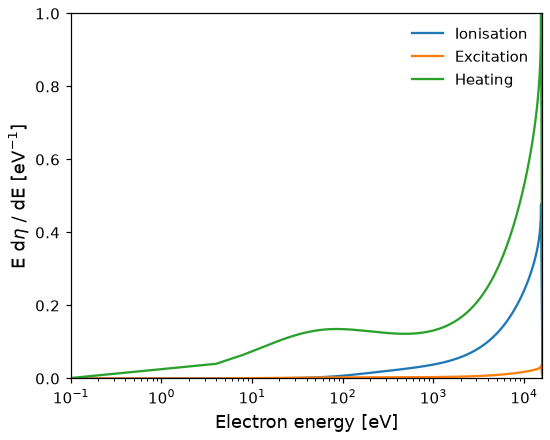

In [6]:
sf.plot_channels(xscalelog=True)

## Comparison with the Saha equation

`add_element_saha()` gives the ion fractions in local thermodynamic equilibrium at the same
temperature, with no recombination rate coefficients. At the low density of the nebular ejecta, the
Saha equation at 6000 K also puts most of the iron in Fe III, but it leaves almost no Fe I or Fe IV,
because the Boltzmann factors of the ionisation potentials (16.2 eV for Fe II and 30.7 eV for
Fe III) are steep at this temperature. The non-thermal balance spreads the iron over more stages.

In [7]:
sf_saha = pynonthermal.SpencerFanoSolver(emin_ev=0.1, emax_ev=16000.0, npts=4096)
sf_saha.add_element_saha(Z=26, n_elem=N_FE_250, temperature=TEMPERATURE, ion_stages=ION_STAGES[:5])
sf_saha.solve(depositionratedensity_ev=deposition_250)

print(f"Saha free electron density: {sf_saha.get_n_e():.3e} cm^-3 (x_e = {sf_saha.get_n_e() / N_FE_250:.3f})")
print()
print(f"{'ion':<8}{'non-thermal balance':>22}{'Saha':>14}")
for ion_stage in ION_STAGES:
    frac_balance = sf.ionpopdict[(26, ion_stage)] / N_FE_250
    frac_saha = sf_saha.ionpopdict.get((26, ion_stage), 0.0) / N_FE_250
    print(f"Fe {ROMAN[ion_stage]:<5}{frac_balance:>22.3e}{frac_saha:>14.3e}")

Saha free electron density: 1.933e+06 cm^-3 (x_e = 1.933)

ion        non-thermal balance          Saha
Fe I                 1.882e-01     1.662e-10
Fe II                3.843e-01     6.658e-02
Fe III               3.113e-01     9.334e-01
Fe IV                1.045e-01     5.045e-12
Fe V                 1.117e-02     1.539e-42
Fe VI                4.502e-04     0.000e+00
Fe VII               7.570e-06     0.000e+00


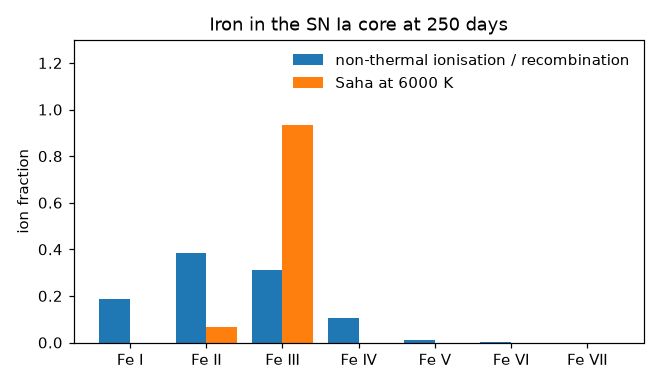

In [8]:
fig, ax = plt.subplots(figsize=(6, 3.5), tight_layout=True)
labels = [f"Fe {ROMAN[ion_stage]}" for ion_stage in ION_STAGES]
fracs_balance = [sf.ionpopdict[(26, ion_stage)] / N_FE_250 for ion_stage in ION_STAGES]
fracs_saha = [sf_saha.ionpopdict.get((26, ion_stage), 0.0) / N_FE_250 for ion_stage in ION_STAGES]
positions = range(len(ION_STAGES))
ax.bar([p - 0.2 for p in positions], fracs_balance, width=0.4, label="non-thermal ionisation / recombination")
ax.bar([p + 0.2 for p in positions], fracs_saha, width=0.4, label=f"Saha at {TEMPERATURE:.0f} K")
ax.set_xticks(list(positions), labels)
ax.set_ylabel("ion fraction")
ax.set_ylim(0, 1.3)  # leave room for the legend above the bars
ax.set_title("Iron in the SN Ia core at 250 days")
ax.legend(frameon=False, loc="upper right")
plt.show()

## Evolution from 150 to 400 days

As the ejecta expand, the density falls as $t^{-3}$, the 56Co decays away, and fewer gamma rays are
absorbed. The non-thermal ionisation rate per ion follows the deposition per nucleus, and the
recombination rate per ion follows $n_e$, which falls with the density. Between 150 and 400 days
the two fall at nearly the same pace, so the ionisation state changes slowly. Each epoch is a new
solver, because the iron number density changes.

 150 d: n_Fe 4.63e+06 cm^-3, deposition  57048.0 eV/s/cm^3, x_e 1.364, 7 iterations
 200 d: n_Fe 1.95e+06 cm^-3, deposition  10564.1 eV/s/cm^3, x_e 1.378, 7 iterations
 250 d: n_Fe 1.00e+06 cm^-3, deposition   2726.8 eV/s/cm^3, x_e 1.367, 7 iterations
 300 d: n_Fe 5.79e+05 cm^-3, deposition    861.7 eV/s/cm^3, x_e 1.339, 7 iterations
 350 d: n_Fe 3.64e+05 cm^-3, deposition    311.1 eV/s/cm^3, x_e 1.297, 7 iterations
 400 d: n_Fe 2.44e+05 cm^-3, deposition    123.2 eV/s/cm^3, x_e 1.243, 7 iterations


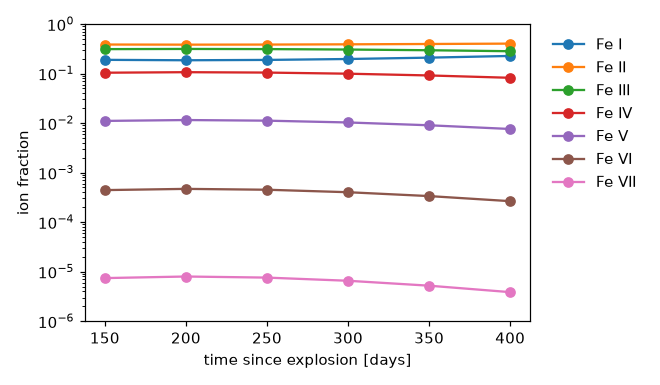

In [9]:
epochs_days = [150, 200, 250, 300, 350, 400]
fractions_by_epoch = []
x_e_by_epoch = []
for t_days in epochs_days:
    n_fe = get_n_fe(t_days)
    sf_epoch = build_solver(n_fe)
    sf_epoch.solve(depositionratedensity_ev=get_deposition_rate_density(t_days))
    fractions_by_epoch.append([sf_epoch.ionpopdict[(26, ion_stage)] / n_fe for ion_stage in ION_STAGES])
    x_e_by_epoch.append(sf_epoch.get_n_e() / n_fe)
    print(
        f"{t_days:4.0f} d: n_Fe {n_fe:.2e} cm^-3, deposition {get_deposition_rate_density(t_days):8.1f} eV/s/cm^3,"
        f" x_e {x_e_by_epoch[-1]:.3f}, {sf_epoch.balance_iterations} iterations"
    )

fig, ax = plt.subplots(figsize=(6, 3.5), tight_layout=True)
for index, ion_stage in enumerate(ION_STAGES):
    ax.plot(epochs_days, [fracs[index] for fracs in fractions_by_epoch], marker="o", label=f"Fe {ROMAN[ion_stage]}")
ax.set_xlabel("time since explosion [days]")
ax.set_ylabel("ion fraction")
ax.set_yscale("log")
ax.set_ylim(1e-6, 1)
ax.legend(frameon=False, loc="upper left", bbox_to_anchor=(1.02, 1.0))
plt.show()

## Notes

- The ion fractions from the balance depend on the deposition rate density, the recombination
  rate coefficients, and the density. Check the sensitivity to each before you draw conclusions.
- `solve()` warns if the ionisation rate out of the top stage of the chain is not small compared
  with the total ionisation rate of the element. Then add a recombination rate coefficient for the
  next stage.
- For the method, see Kozma, C. & Fransson, C. (1992), "Gamma-ray deposition and nonthermal
  excitation in supernovae", The Astrophysical Journal, 390, 602-621, DOI 10.1086/171311.